Task 2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

YEARS = [2004, 2005, 2006, 2007, 2008]

cols = ["Year", "Month", "DayOfWeek", "CRSDepTime", "CRSArrTime", "ArrDelay", "DepDelay", "Diverted", "Cancelled", "TailNum", "Origin", "Dest", "Distance", "UniqueCarrier"]

flights_by_year = []
for y in YEARS:
    df = pd.read_csv(f"./dataverse_files/{y}.csv", low_memory=False)
    df = df[df["Cancelled"] == 0]
    flights_by_year.append(df)

flights = pd.concat(flights_by_year, ignore_index=True)
flights = flights[cols]
flights["ArrDelay"] = pd.to_numeric(flights["ArrDelay"], errors="coerce")
flights["DepDelay"] = pd.to_numeric(flights["DepDelay"], errors="coerce")
flights["Diverted"] = pd.to_numeric(flights["Diverted"],   errors="coerce")
flights["Distance"] = pd.to_numeric(flights["Distance"],   errors="coerce")
flights["CRSDepTime"] = pd.to_numeric(flights["CRSDepTime"], errors="coerce")
flights["CRSArrTime"] = pd.to_numeric(flights["CRSArrTime"], errors="coerce")
flights["UniqueCarrier"] = pd.Categorical(flights["UniqueCarrier"]).codes
flights["DepHour"] = pd.to_numeric(flights["CRSDepTime"], errors="coerce") // 100
print(f"Loaded {len(flights):,} rows(flights)")
pd.set_option('display.float_format', '{:.2f}'.format)
print(flights.describe())

planes = pd.read_csv("./dataverse_files/plane-data.csv", low_memory=False)
planes = planes[["tailnum", "year"]].rename(columns={"tailnum": "TailNum", "year": "MYear"})
planes["MYear"] = pd.to_numeric(planes["MYear"], errors="coerce")
print(f"Loaded {len(planes):,} rows(planes)")
pd.set_option('display.float_format', '{:.2f}'.format)
print(planes.describe())

airports = pd.read_csv("./dataverse_files/airports.csv")[["iata", "lat", "long"]]
print(f"Loaded {len(airports):,} rows(airports)")
pd.set_option('display.float_format', '{:.2f}'.format)
print(airports.describe())

Loaded 30,645,609 rows(flights)
             Year       Month   DayOfWeek  CRSDepTime  CRSArrTime    ArrDelay  \
count 30645609.00 30645609.00 30645609.00 30645609.00 30645609.00 30578778.00   
mean      2005.70        6.23        3.94     1334.07     1497.76        8.32   
std          1.26        3.47        1.99      463.77      479.93       36.29   
min       2004.00        1.00        1.00        0.00        0.00    -1302.00   
25%       2005.00        3.00        2.00      930.00     1118.00       -9.00   
50%       2006.00        6.00        4.00     1325.00     1520.00       -1.00   
75%       2007.00        9.00        6.00     1722.00     1910.00       12.00   
max       2008.00       12.00        7.00     2359.00     2400.00     2598.00   

         DepDelay    Diverted   Cancelled    Distance  UniqueCarrier  \
count 30645609.00 30645609.00 30645609.00 30645609.00    30645609.00   
mean         9.68        0.00        0.00      724.82          12.90   
std         33.13     

2(a) What are the best times and days of the week to minimise delays each year?

2004: best hour = 4:00, best day = Sat
2005: best hour = 5:00, best day = Sat
2006: best hour = 5:00, best day = Sat
2007: best hour = 3:00, best day = Sat
2008: best hour = 4:00, best day = Sat


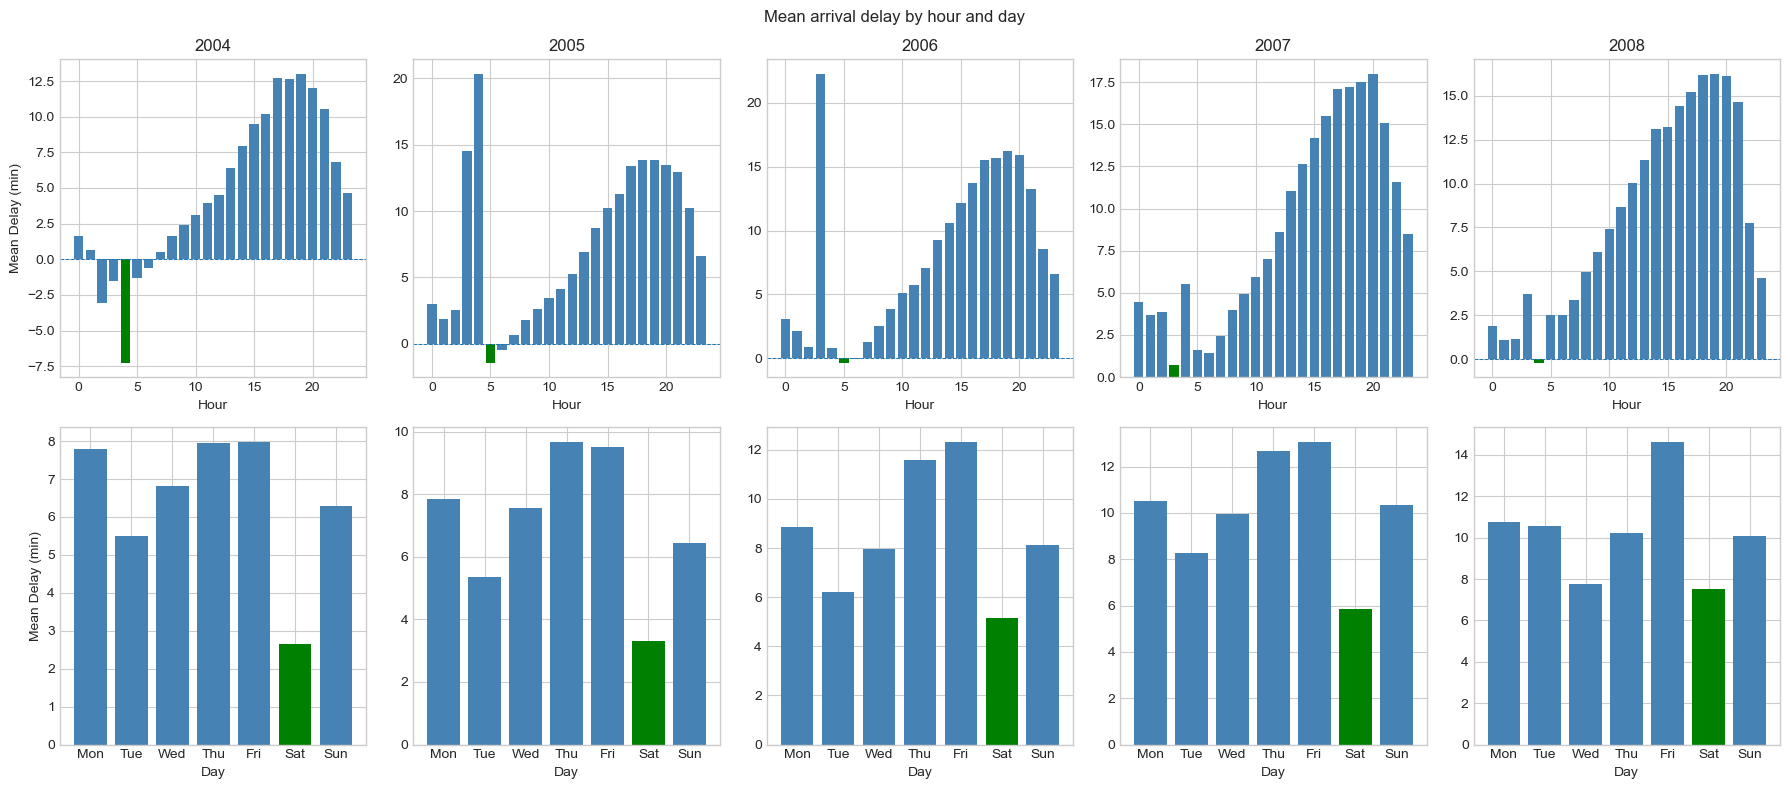

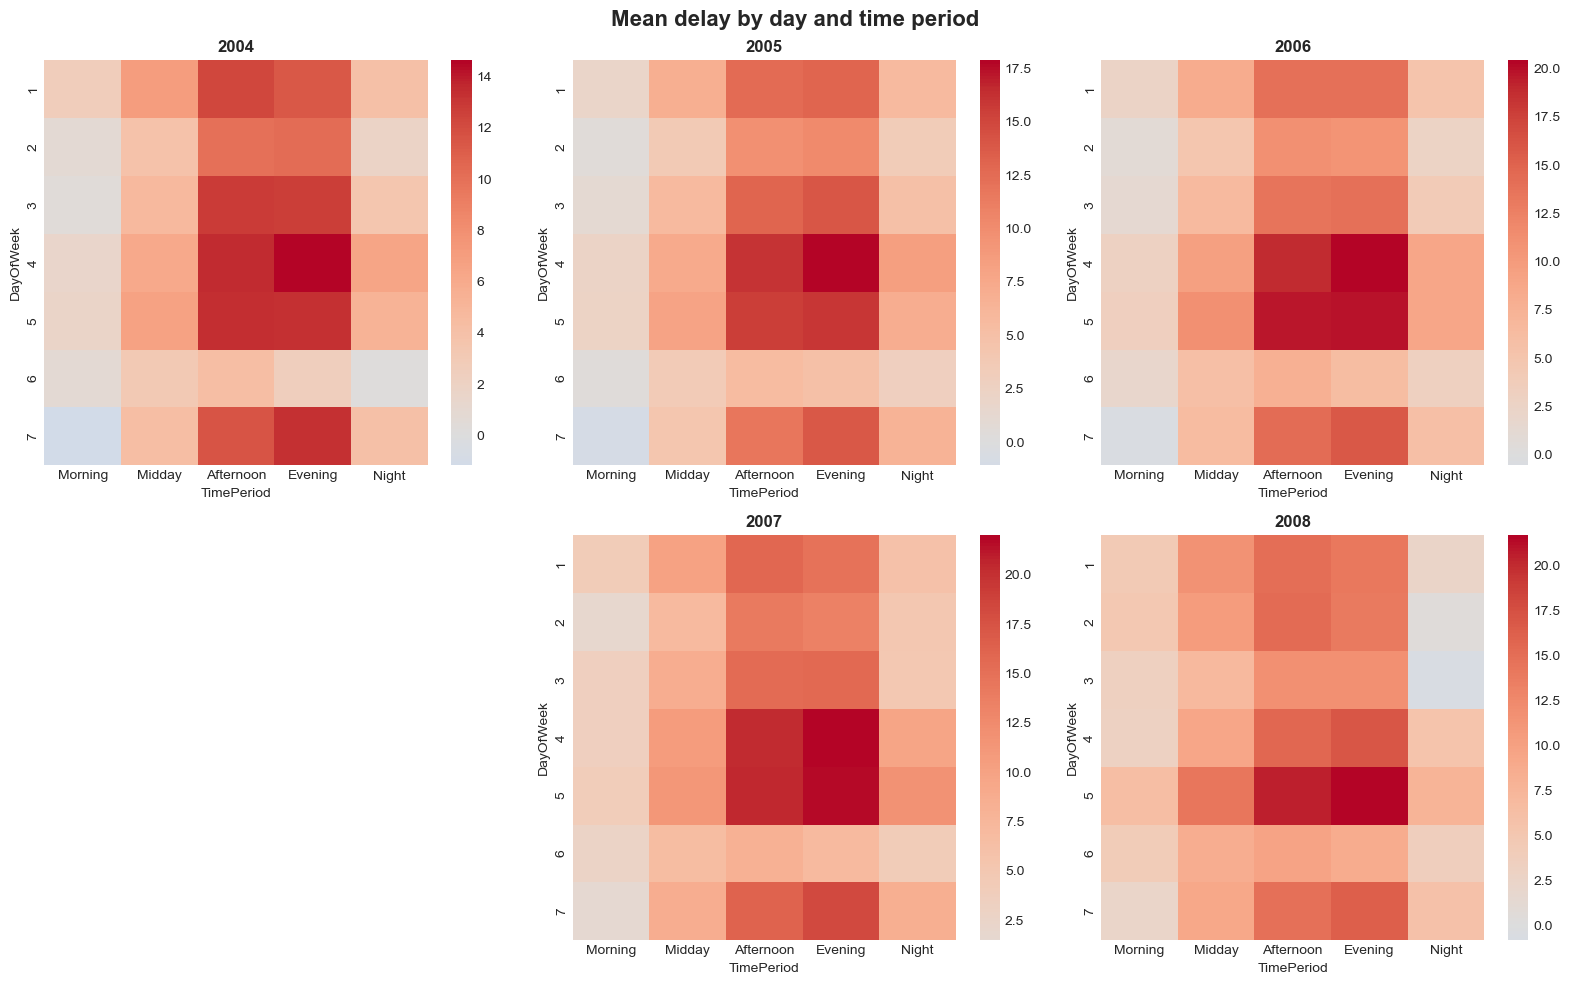

In [ ]:
import seaborn as sns
import matplotlib.gridspec as gridspec
day_names = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}

fig, ax = plt.subplots(2, len(YEARS), figsize=(18, 8))
fig.suptitle("Mean arrival delay by hour and day")

for i, year in enumerate(YEARS):
    df = flights[flights["Year"] == year].dropna(subset=["ArrDelay"])
    by_hour = df.groupby("DepHour")["ArrDelay"].mean()
    by_day  = df.groupby("DayOfWeek")["ArrDelay"].mean()
    h_best = by_hour.idxmin()
    d_best = by_day.idxmin()
    print(f"{year}: best hour = {h_best}:00, best day = {day_names[d_best]}")

    ax[0, i].bar(by_hour.index, by_hour, color=["green" if h == h_best else "steelblue" for h in by_hour.index])
    ax[1, i].bar([day_names[d] for d in by_day.index], by_day, color=["green" if d == d_best else "steelblue" for d in by_day.index])

    for j in (0, 1):
        ax[j, i].axhline(0, ls="--", lw=0.7)
        ax[j, i].set_title(year if j == 0 else "")
        ax[j, i].set_xlabel("Hour" if j == 0 else "Day")

ax[0, 0].set_ylabel("Mean Delay (min)")
ax[1, 0].set_ylabel("Mean Delay (min)")

plt.tight_layout()
plt.show()

def period(hour):
    if 5 <= hour < 10:
        return "Morning"
    elif 10 <= hour < 15:
        return "Midday"
    elif 15 <= hour < 19:
        return "Afternoon"
    elif 19 <= hour < 23:
        return "Evening"
    else:
        return "Night"

fig, axes = plt.subplot_mosaic(
    """
    ABC
    .DE
    """,
    figsize=(16, 10)
)

ax_list = [axes['A'], axes['B'], axes['C'], axes['D'], axes['E']]

for i, year in enumerate(YEARS):
    ax = ax_list[i]

    df = flights[flights["Year"] == year].dropna(subset=["ArrDelay"]).copy()
    df["TimePeriod"] = df["DepHour"].apply(period)

    pivot = df.pivot_table(
        values="ArrDelay",
        index="DayOfWeek",
        columns="TimePeriod",
        aggfunc="mean"
    )

    pivot = pivot.reindex(index=sorted(pivot.index))
    pivot = pivot[["Morning", "Midday", "Afternoon", "Evening", "Night"]]

    sns.heatmap(pivot, ax=ax, cmap="coolwarm", center=0)

    ax.set_title(str(year), weight="bold")

plt.suptitle("Mean delay by day and time period", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

2(b) Evaluate whether older planes suffer more delays on a year-to-year basis

2004: r=-0.279, p=0.063
2005: r=-0.093, p=0.540
2006: r=-0.268, p=0.068
2007: r=0.609, p=0.000
2008: r=0.645, p=0.000


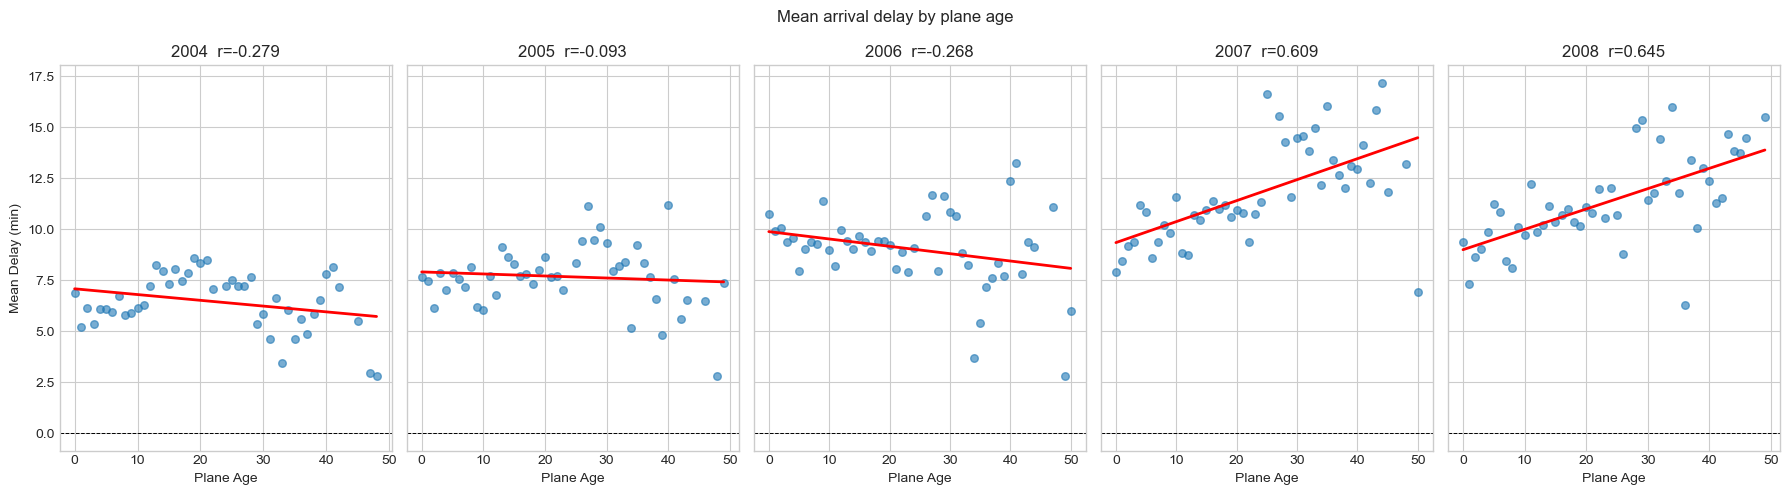

In [ ]:
df_b = flights.merge(planes, on="TailNum", how="inner").dropna(subset=["ArrDelay", "MYear"])
df_b["PlaneAge"] = df_b["Year"] - df_b["MYear"]
df_b = df_b[(df_b["PlaneAge"] >= 0) & (df_b["PlaneAge"] <= 50)]

fig, ax = plt.subplots(1, len(YEARS), figsize=(18, 5), sharey=True)
fig.suptitle("Mean arrival delay by plane age")

for i, year in enumerate(YEARS):
    df_y = df_b[df_b["Year"] == year]

    by_age = df_y.groupby("PlaneAge")["ArrDelay"].agg(["mean", "count"])
    by_age = by_age[by_age["count"] >= 50]
    r, p = pearsonr(by_age.index, by_age["mean"])
    print(f"{year}: r={r:.3f}, p={p:.3f}")
    
    ax[i].scatter(by_age.index, by_age["mean"], s=30, alpha=0.6)
    z = np.polyfit(by_age.index, by_age["mean"], 1)
    x = np.linspace(by_age.index.min(), by_age.index.max(), 100)
    ax[i].plot(x, np.polyval(z, x), lw=2, color="red")
    ax[i].axhline(0, color="black", ls="--", lw=0.7)
    ax[i].set(title=f"{year}  r={r:.3f}", xlabel="Plane Age")

ax[0].set_ylabel("Mean Delay (min)")
plt.tight_layout()
plt.show()

2(c) For each year, fit a logistic regression model for the probability of diverted US flights

2004: diversion rate = 0.197%
2005: diversion rate = 0.200%
2006: diversion rate = 0.231%
2007: diversion rate = 0.236%
2008: diversion rate = 0.243%
Feature                   2004        2005        2006        2007        2008
Month                   0.0656     -0.0509      0.0171     -0.0214     -0.1058
DayOfWeek              -0.0006     -0.0378      0.0226     -0.0253     -0.0397
CRSDepTime             -0.1035     -0.1127     -0.0916     -0.2088     -0.3121
CRSArrTime              0.1912      0.1744      0.1473      0.2651      0.2357
OriginLat               0.0588      0.0522      0.0552      0.0425      0.0652
OriginLong              0.0473      0.0348      0.1169      0.0253      0.1222
DestLat                 0.0458      0.0611      0.0554      0.0412      0.1117
DestLong                0.0195      0.1184      0.1245      0.1799      0.0238
Distance                0.2974      0.3240      0.4034      0.3382      0.2812
UniqueCarrier           0.0159     -0.0187      0.0235     -

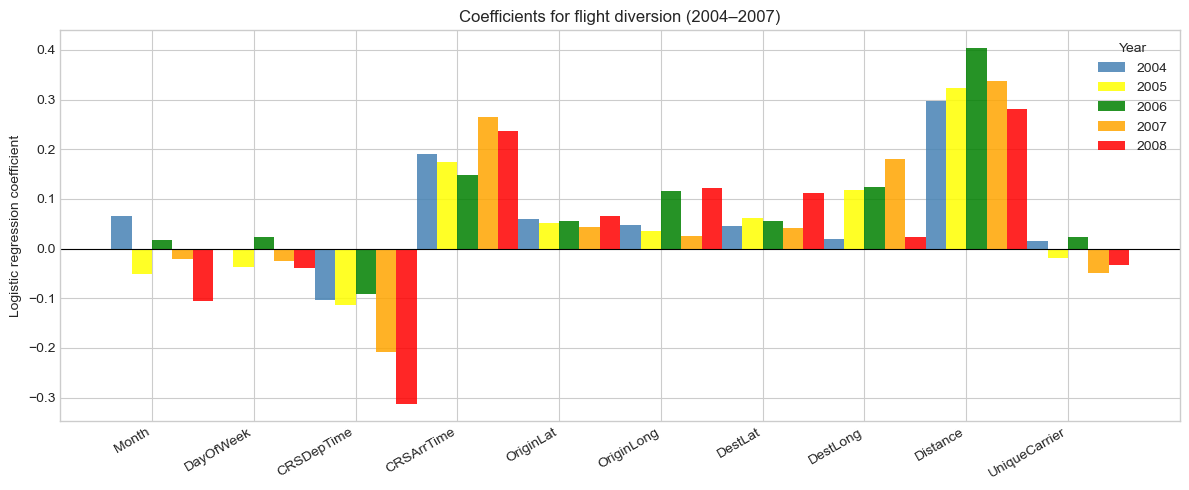

In [ ]:
df_c = flights.copy()
df_c = df_c.merge(airports.rename(columns={"iata":"Origin", "lat":"OriginLat", "long":"OriginLong"}), on="Origin", how="left")
df_c = df_c.merge(airports.rename(columns={"iata":"Dest",   "lat":"DestLat",   "long":"DestLong"}),   on="Dest",   how="left")

FEATURES = ["Month", "DayOfWeek", "CRSDepTime", "CRSArrTime", "OriginLat", "OriginLong", "DestLat", "DestLong", "Distance", "UniqueCarrier"]

df_c = df_c.dropna(subset=FEATURES + ["Diverted"])
df_c["Diverted"] = df_c["Diverted"].astype(int)

coefs = {}
for year in YEARS:
    df_y = df_c[df_c["Year"] == year]
    X = StandardScaler().fit_transform(df_y[FEATURES].values.astype(float))
    y = df_y["Diverted"].values
    model = LogisticRegression(max_iter=600, class_weight="balanced", random_state=42)
    model.fit(X, y)
    coefs[year] = model.coef_[0]
    print(f"{year}: diversion rate = {y.mean()*100:.3f}%")

coef_df = pd.DataFrame(coefs, index=FEATURES)

print(f"{'Feature':<18}", end="")
for year in YEARS:
    print(f"{year:>12}", end="")
print()

for feature in FEATURES:
    print(f"{feature:<18}", end="")
    for year in YEARS:
        print(f"{coefs[year][FEATURES.index(feature)]:12.4f}", end="")
    print()
x = np.arange(len(FEATURES))
width = 0.2
colors = ["steelblue", "yellow", "green", "orange", "red"]

x = np.arange(len(FEATURES))
width = 0.2
colors = ["steelblue", "yellow", "green", "orange", "red"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, year in enumerate(YEARS):
    ax.bar(x + i * width, coef_df[year], width, label=str(year), color=colors[i], alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(FEATURES, rotation=30, ha="right")
ax.set_ylabel("Logistic regression coefficient")
ax.set_title("Coefficients for flight diversion (2004–2007)")
ax.legend(title="Year")
plt.tight_layout()
plt.show()